## 分类的基本概念

### 基本概念

分类（Classification）是一种重要的数据分析形式，它提取刻画重要数据类的模型。这种模型称为分类器，预测分类的（离散的、无序的类标号。这些类别可以用离散值表示，其中值之间的次序没有意义。

分类也可定义为：

分类的任务就是通过学习得到一个目标函数(Target Function)ƒ ，把每个属性集x映射到一个预先定义的类标号y。

## 决策树概述

决策树(Decision Tree)是有监督学习中的一种算法，并且是一种基本的分类与回归的方法。也就是说，决策树有两种:分类树和回归树。这里我们主要讨论分类树。

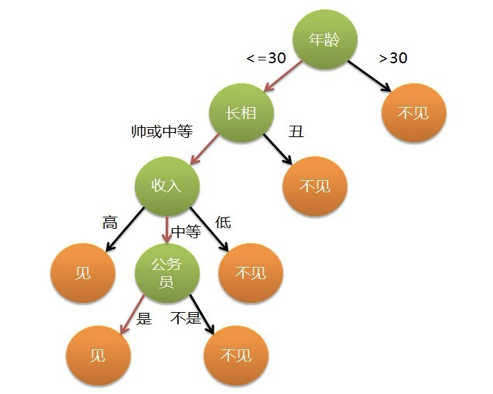

通过上面的例子，我们了很容易理解：决策树算法的本质是树形结构，我们可以通过一些精心设计的问题，就可以对数据进行分类了。在这里，我们需要理解三个概念：

| 节点 | 说明 ||
| :------:| :------: ||
| 根结点 | 没有进边，有出边 |
| 中间节点 | 既有进边也有出边，但进边有且仅有一条，出边可以有很多条 |
| 叶节点 | 只有进边，没有出边，进边有且仅有一条，每个叶节点都有一个类别标签 |
| *父节点和子节点 | 在两个相连的两个节点中，更靠近根节点的是父节点，另一个则是子节点，两者是相对的。|

我们可以把决策树看作是一个if-then规则的集合。将决策树转换成if-then规则的过程是这样的:

- 由决策树的根节点到叶节点的每一条路径构建一条规则
- 路径上中间节点的特征对应着规则的条件，叶节点的类标签对应着规则的结论

决策树的路径或者其对应的if-then规则集合有一个重要的性质:互斥并且完备。也就是说，每一个实例都被有且仅有一条路径或者规则所覆盖。这里的覆盖是指实例的特征与路径上的特征一致，或实例满足规则的条件。


## 决策树原理

决策树学习算法包括3部分：特征选择、决策树的生成和决策树的剪枝。常用的算法有ID3、
C4.5和CART。

## sklearn实现决策树

```
DecisionTreeClassifier(criterion="gini",
                       splitter="best",
                       max_depth=None,
                       min_samples_split=2,
                       min_samples_leaf=1,
                       min_weight_fraction_leaf=0.,
                       max_features=None,
                       random_state=None,
                       max_leaf_nodes=None,
                       min_impurity_decrease=0.,
                       min_impurity_split=None,
                       class_weight=None,
                       presort=False)
```

**较为重要的参数：**

`criterion`：用以设置用信息熵还是基尼系数计算

- criterion='gini',分裂节点时评价准则是Gini指数
- criterion='entropy',分裂节点时的评价指标是信息增益 

`splitter`：指定分支模式

- splitter='best',表示选择最优的分裂策略
- splitter='random',表示选择最好的随机切分策略

`max_depth`：最大深度，防止过拟合

`min_samples_leaf`：限定每个节点分枝后子节点至少有多少个数据，否则就不分枝

- 如果为整数，则min_samples_split就是最少样本数
- 如果为浮点数(0到1之间)，则每个叶子节点最少样本数为ceil(min_samples_leaf * n_samples)

### 导入需要的算法库和模块

In [1]:
import pandas as pd
from sklearn import tree
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

### 探索数据集

In [2]:
wine = load_wine()

In [3]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
pd.concat([pd.DataFrame(wine.data, columns=wine.feature_names),pd.DataFrame(wine.target,columns=['class'])],axis=1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


### 划分训练集和测试集

In [5]:
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=123)

In [6]:
X_train.shape

(124, 13)

In [7]:
X_test.shape

(54, 13)

### 建立模型

In [8]:
clf = tree.DecisionTreeClassifier(criterion="entropy")
clf = clf.fit(X_train, y_train)

In [9]:
score = clf.score(X_test, y_test)   # 返回预测的准确度
score

0.9629629629629629

In [10]:
clf.predict(X_test)

array([2, 1, 2, 1, 1, 2, 0, 2, 2, 1, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2,
       2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 2, 1, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 2, 1])

In [11]:
y_test

array([2, 1, 2, 1, 1, 2, 0, 2, 2, 1, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2,
       2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2, 2, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 2, 2, 1])

### 探索决策树

In [12]:
clf.feature_importances_

array([0.04317242, 0.02563285, 0.        , 0.        , 0.0211198 ,
       0.        , 0.14515492, 0.        , 0.06987497, 0.03635566,
       0.        , 0.24586357, 0.4128258 ])

In [15]:
feature_name = feature_name = ['酒精',
                '苹果酸',
                '灰','灰的碱性',
                '镁',
                '总酚',
                '类黄酮',
                '非黄烷类酚类',
                '花青素',
                '颜色强度',
                '色调',
                'od280/od315稀释葡萄酒',
                '脯氨酸']
sorted([*zip(feature_name, clf.feature_importances_)], key=lambda x: x[1], reverse=True)

[('脯氨酸', 0.4128257988580204),
 ('od280/od315稀释葡萄酒', 0.2458635717188427),
 ('类黄酮', 0.14515492446057987),
 ('花青素', 0.06987497123461893),
 ('酒精', 0.04317242284313755),
 ('颜色强度', 0.0363556587867744),
 ('苹果酸', 0.025632852485582315),
 ('镁', 0.021119799612443865),
 ('灰', 0.0),
 ('灰的碱性', 0.0),
 ('总酚', 0.0),
 ('非黄烷类酚类', 0.0),
 ('色调', 0.0)]

### 剪枝参数

在不加限制的情况下，一棵决策树会生长到衡量不纯度的指标最优，或者没有更多的特征可用为止。这样的决策树往往会过拟合，这就是说，它会在训练集上表现很好，在测试集上却表现糟糕。我们收集的样本数据不可能和整体的状况完全一致，因此当一棵决策树对训练数据有了过于优秀的解释性，它找出的规则必然包含了训练样本中的噪声，并使它对未知数据的拟合程度不足。

- max_depth

限制树的最大深度，超过设定深度的树枝全部剪掉

这是用得最广泛的剪枝参数，在高维度低样本量时非常有效。决策树多生长一层，对样本量的需求会增加一倍，所以限制树深度能够有效地限制过拟合。在集成算法中也非常实用。实际使用时，建议从=3开始尝试，看看拟合的效果再决定是否增加设定深度。

- min_samples_leaf & min_samples_split

min_samples_leaf限定，一个节点在分枝后的每个子节点都必须包含至少min_samples_leaf个训练样本，否则分枝就不会发生，或者，分枝会朝着满足每个子节点都包含min_samples_leaf个样本的方向去发生

一般搭配max_depth使用，在回归树中有神奇的效果，可以让模型变得更加平滑。这个参数的数量设置得太小会引起过拟合，设置得太大就会阻止模型学习数据。一般来说，建议从=5开始使用。如果叶节点中含有的样本量变化很大，建议输入浮点数作为样本量的百分比来使用。同时，这个参数可以保证每个叶子的最小尺寸，可以在回归问题中避免低方差，过拟合的叶子节点出现。对于类别不多的分类问题，=1通常就是最佳选择。

min_samples_split限定，一个节点必须要包含至少min_samples_split个训练样本，这个节点才允许被分枝，否则分枝就不会发生。

#### 确认最优参数

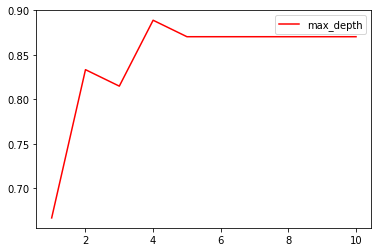

In [43]:
import matplotlib.pyplot as plt

test = []
for i in range(10):
    clf = tree.DecisionTreeClassifier(max_depth=i+1
                                      ,criterion="entropy"
                                      ,random_state=30
                                      ,splitter="random"
                                     )
    clf = clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    test.append(score)
plt.plot(range(1,11), test, color="red", label="max_depth")
plt.legend()
plt.show()

## 算法总结

**决策树的优点：**

- 决策树可以可视化，易于理解和解释;
- 数据准备工作很少，其他很多算法通常都需要数据规范化，需要创建虚拟变量并删除空值等;
- 能够同时处理数值和分类数据，既可以做回归又可以做分类。其他技术通常专门用于分析仅具有一种变量类型的数据集;
- 效率高，决策树只需要一次构建，反复使用，每一次预测的最大计算次数不超过决策树的深度;
- 能够处理多输出问题，即含有多个标签的问题，注意与一个标签中含有多种标签分类的问题区别开;
- 是一个白盒模型，结果很容易能够被解释。如果在模型中可以观察到给定的情况，则可以通过布尔逻辑轻松解释条件。相反，在黑盒模型中(例如，在人工神经网络中)，结果可能更难以解释。

**决策树的缺点：**
- 递归生成树的方法很容易出现过拟合；
- 决策树可能是不稳定的，因为即使非常小的变异，可能会产生一颗完全不同的树
- 如果某些分类占优势，决策树将会创建一棵有偏差的树。因此，建议在拟合决策树之前平衡数据集。